,station,peak_time_s,peak_amplitude,peak_distance_m,peak_source_time_s,peak_phi_deg,peak_f_obs_hz,side,distance_km,station_distance_km
0,W_00.5km,19.009726,0.001055,792.235867,16.7,36.151307,17.070599,West,0.792236,0.5
1,E_00.5km,21.215805,0.000953,862.921120,18.7,38.652749,16.820942,East,0.862921,0.5
2,W_01.0km,26.782775,0.000582,1537.591935,22.3,36.184979,16.126941,West,1.537592,1.0
3,E_01.0km,31.559633,0.000492,1735.454185,26.5,39.865644,15.607955,East,1.735454,1.0
4,W_01.5km,32.662507,0.000406,2250.940041,26.1,36.460208,15.511033,West,2.250940,1.5


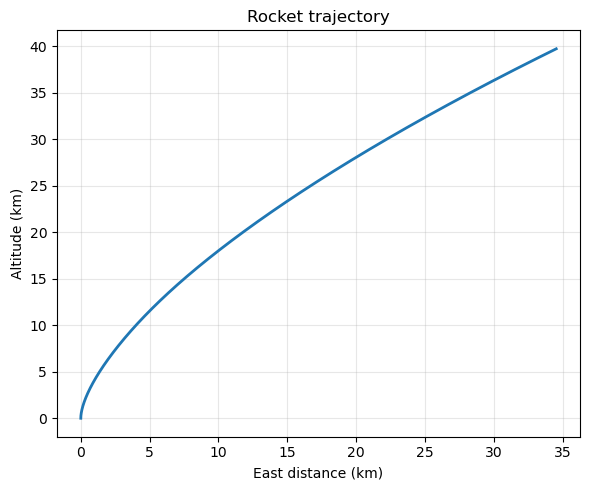

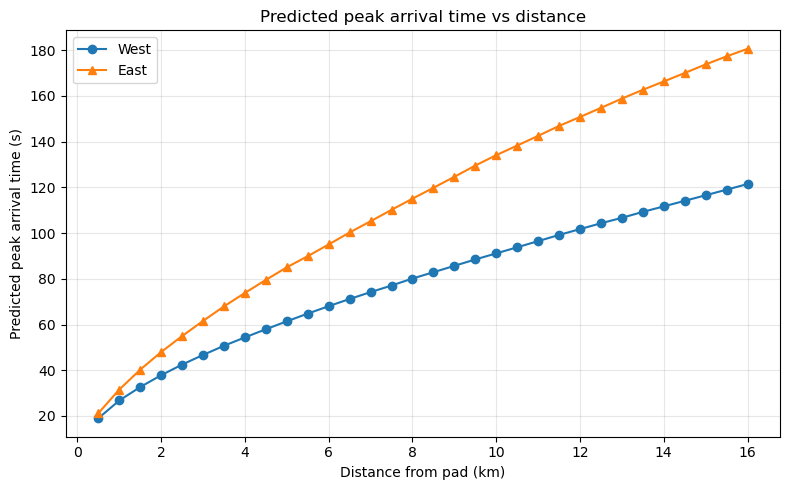

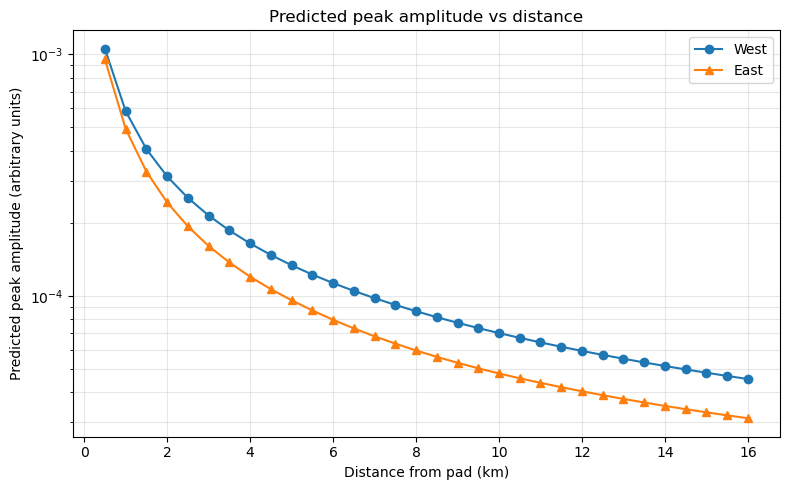

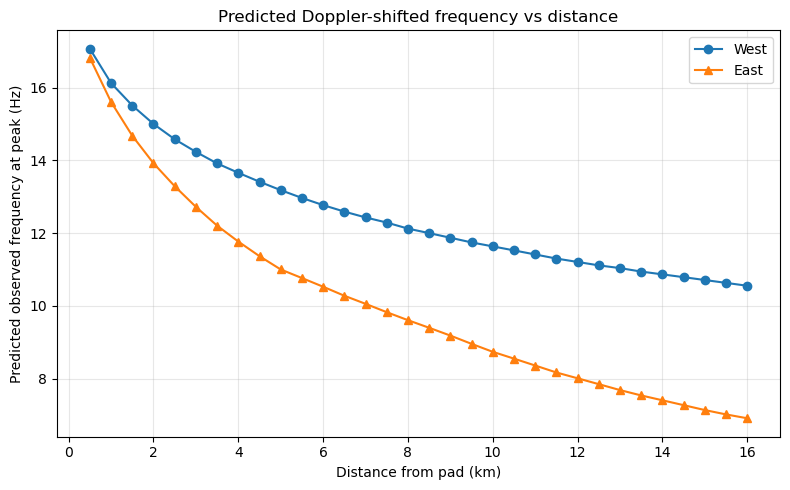

Saved synthetic_east_west_station_line_peak_metrics.csv
T+ 56 s | z =   7.74 km | x =   2.70 km | speed =   344.3 m/s | pitch =  22.7 deg
T+ 70 s | z =  12.54 km | x =   5.69 km | speed =   461.7 m/s | pitch =  29.0 deg
T+128 s | z =  45.89 km | x =  43.36 km | speed =  1443.5 m/s | pitch =  55.1 deg


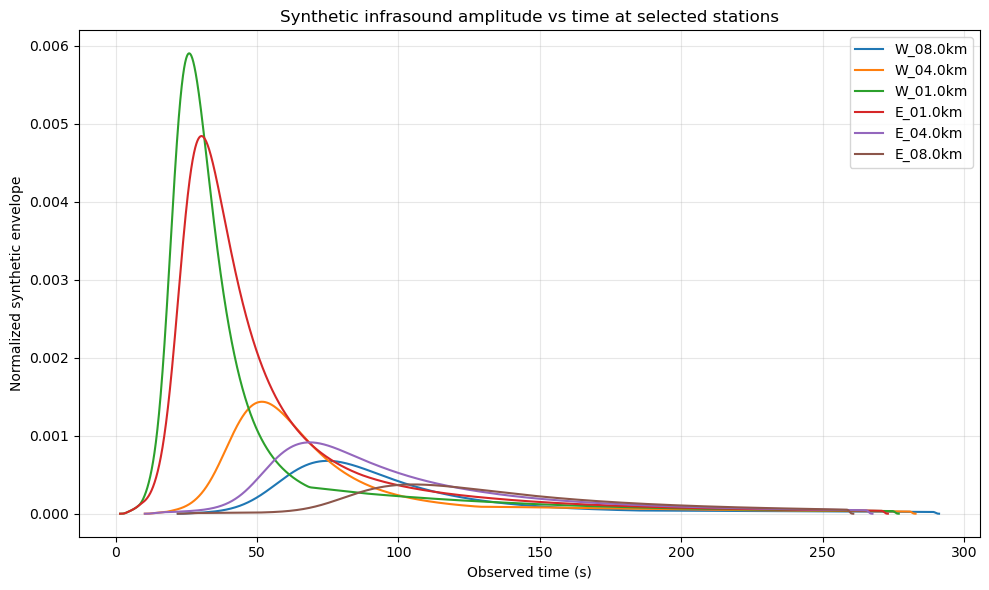

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point this at wherever you unpacked the zip
sys.path.append('../rocket_infrasound_model')

from rocket_infrasound_model.trajectory import GravityTurnParameters
from rocket_infrasound_model.model import RocketModel, Station
from rocket_infrasound_model.plotting import plot_trajectory

LINE_SOURCE = False
# ------------------------------------------------------------------
# Build synthetic station line: west and east, every 0.5 km to 16 km
# ------------------------------------------------------------------
distances_km = np.arange(0.5, 16.0 + 0.001, 0.5)

stations = []
for d in distances_km:
    stations.append(Station(name=f"W_{d:04.1f}km", x_m=-1000.0 * d, z_m=0.0))
    stations.append(Station(name=f"E_{d:04.1f}km", x_m=+1000.0 * d, z_m=0.0))

# ------------------------------------------------------------------
# Define a simple rocket model
# ------------------------------------------------------------------

traj = GravityTurnParameters(
    thrust_N = 3.74e7 * 0.95,     # 8.4 million lbf / 37.4 MN average for 2 minutes
    #thrust_N = 3.2e7,
    m0_kg = 2.61e6,      # initial mass (~SLS scale)
    mdot_kgps = 1.2081e4,       # mass flow rate (kg/s)
    g = 9.81,
    t_vertical=6.0,
    t_pitchover=10.0,
    pitch_rate_deg=0.45,
    max_pitch_deg=80.0,
    area_m2=78.0,
    rho0=1.225,
    scale_height_m=8500.0,
)

if LINE_SOURCE:
    model = RocketModel(
        trajectory=traj,
        c_mps=343.0,
        q0=1.0,
        phi0_deg=30.0,
        sigma_deg=20.0,
        source_model="plume",
        plume_length_m=100.0,
        n_plume_sources=10,
        plume_decay_scale=3.0,
    )
else:
    model = RocketModel(
        trajectory=traj,
        c_mps=343.0,
        q0=1.0,
        phi0_deg=30.0,
        sigma_deg=20.0,
        source_model="point",
    )

# ------------------------------------------------------------------
# Predict
# ------------------------------------------------------------------
result = model.predict_network(stations, t_max=120.0, dt=0.1)
peak_df = result.peak_metrics.copy()

# Add side and distance columns for easier plotting
peak_df["side"] = peak_df["station"].str[0].map({"W": "West", "E": "East"})
peak_df["distance_km"] = peak_df["peak_distance_m"] / 1000.0
peak_df["station_distance_km"] = peak_df["station"].str.extract(r'_(\d+\.\d+)km')[0].astype(float)
display(peak_df.head())

# ------------------------------------------------------------------
# Plot 1: trajectory
# ------------------------------------------------------------------
fig, ax = plot_trajectory(model, t_max=120.0, dt=0.1)
plt.show()

# ------------------------------------------------------------------
# Plot 2: peak arrival time vs distance, east vs west
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = peak_df[peak_df["side"] == side]
    ax.plot(
        sub["station_distance_km"],
        sub["peak_time_s"],
        marker=marker,
        linestyle="-",
        label=side,
    )

ax.set_xlabel("Distance from pad (km)")
ax.set_ylabel("Predicted peak arrival time (s)")
ax.set_title("Predicted peak arrival time vs distance")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Plot 3: peak amplitude vs distance, east vs west
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = peak_df[peak_df["side"] == side]
    ax.plot(
        sub["station_distance_km"],
        sub["peak_amplitude"],
        marker=marker,
        linestyle="-",
        label=side,
    )

ax.set_xlabel("Distance from pad (km)")
ax.set_ylabel("Predicted peak amplitude (arbitrary units)")
ax.set_title("Predicted peak amplitude vs distance")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Plot 4: observed frequency at peak vs distance
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = peak_df[peak_df["side"] == side]
    ax.plot(
        sub["station_distance_km"],
        sub["peak_f_obs_hz"],
        marker=marker,
        linestyle="-",
        label=side,
    )

ax.set_xlabel("Distance from pad (km)")
ax.set_ylabel("Predicted observed frequency at peak (Hz)")
ax.set_title("Predicted Doppler-shifted frequency vs distance")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Optional: save synthetic peak table
# ------------------------------------------------------------------
out_csv = Path("./synthetic_east_west_station_line_peak_metrics.csv")
peak_df.to_csv(out_csv, index=False)
print(f"Saved {out_csv}")



from rocket_infrasound_model.trajectory import gravity_turn_trajectory
state = gravity_turn_trajectory(np.arange(0, 128.1, 0.1), traj)
speed = np.sqrt(state["vx_mps"]**2 + state["vz_mps"]**2)
for tcheck in [56, 70, 128]:
    i = int(round(tcheck / 0.1))
    print(
        f"T+{tcheck:3d} s | "
        f"z = {state['z_m'][i]/1000:6.2f} km | "
        f"x = {state['x_m'][i]/1000:6.2f} km | "
        f"speed = {speed[i]:7.1f} m/s | "
        f"pitch = {np.rad2deg(state['theta_rad'][i]):5.1f} deg"
    )
import numpy as np
import pandas as pd


def synthesize_station_envelope(
    df_station: pd.DataFrame,
    t_start: float | None = None,
    t_end: float | None = None,
    dt_obs: float = 0.05,
    pulse_width_s: float = 0.5,
    normalize: bool = False,
):
    """
    Convert source-time predictions for one station into a regular synthetic
    infrasound envelope as a function of observed time.

    Parameters
    ----------
    df_station : pandas.DataFrame
        Output from model.predict_station(station), containing at least:
        - t_obs_s
        - amplitude
    t_start, t_end : float or None
        Observed-time limits. If None, inferred from data.
    dt_obs : float
        Time sampling interval for receiver time axis.
    pulse_width_s : float
        Standard deviation of Gaussian pulse used to smear each emitted packet.
        This controls how smooth/broad the synthetic envelope is.
    normalize : bool
        If True, scale output so max amplitude is 1.

    Returns
    -------
    pandas.DataFrame
        Columns:
        - t_obs_s
        - amplitude_env
    """
    t_arr = np.asarray(df_station["t_obs_s"], dtype=float)
    a_arr = np.asarray(df_station["amplitude"], dtype=float)

    good = np.isfinite(t_arr) & np.isfinite(a_arr) & (a_arr > 0)
    t_arr = t_arr[good]
    a_arr = a_arr[good]

    if len(t_arr) == 0:
        return pd.DataFrame({"t_obs_s": [], "amplitude_env": []})

    if t_start is None:
        t_start = float(np.nanmin(t_arr)) - 3 * pulse_width_s
    if t_end is None:
        t_end = float(np.nanmax(t_arr)) + 3 * pulse_width_s

    t_obs = np.arange(t_start, t_end + dt_obs, dt_obs)
    env = np.zeros_like(t_obs)

    # Deposit a Gaussian packet at each arrival time
    for ti, ai in zip(t_arr, a_arr):
        env += ai * np.exp(-0.5 * ((t_obs - ti) / pulse_width_s) ** 2)

    if normalize and np.nanmax(env) > 0:
        env = env / np.nanmax(env)

    return pd.DataFrame({
        "t_obs_s": t_obs,
        "amplitude_env": env,
    })
fig, ax = plt.subplots(figsize=(10, 6))

for sta_name in ["W_08.0km", "W_04.0km", "W_01.0km", "E_01.0km", "E_04.0km", "E_08.0km"]:
    env_sta = synthesize_station_envelope(
        result.time_series[sta_name],
        dt_obs=0.05,
        pulse_width_s=0.5,
        normalize=False,
    )
    ax.plot(env_sta["t_obs_s"], env_sta["amplitude_env"], label=sta_name)

ax.set_xlabel("Observed time (s)")
ax.set_ylabel("Normalized synthetic envelope")
ax.set_title("Synthetic infrasound amplitude vs time at selected stations")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

,station,peak_time_s,peak_amplitude,peak_distance_m,peak_source_time_s,peak_phi_deg,peak_f_obs_hz,side,distance_km,station_distance_km,time_since_launch_s
0,W_00.5km,19.009726,0.001055,792.235867,16.7,36.151307,17.070599,West,0.792236,0.5,19.009726
1,E_00.5km,21.215805,0.000953,862.921120,18.7,38.652749,16.820942,East,0.862921,0.5,21.215805
2,W_01.0km,26.782775,0.000582,1537.591935,22.3,36.184979,16.126941,West,1.537592,1.0,26.782775
3,E_01.0km,31.559633,0.000492,1735.454185,26.5,39.865644,15.607955,East,1.735454,1.0,31.559633
4,W_01.5km,32.662507,0.000406,2250.940041,26.1,36.460208,15.511033,West,2.250940,1.5,32.662507


Amplitude fit:
log10(A) = -3.2760 + -0.9577 log10(d_km)
A = 5.2964e-04 * d_km^(-0.9577)


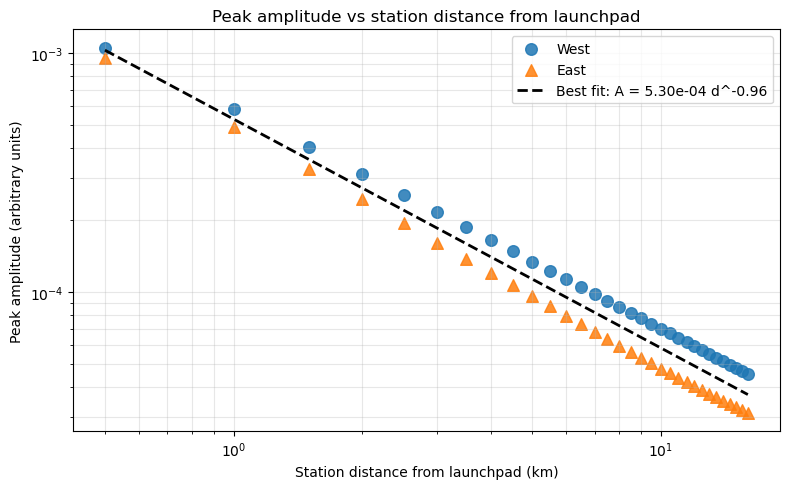


Time fit:
Linear:    t = 29.5685 + 8.0015 d_km
Quadratic: t = 19.6087 + 11.5168 d_km + -0.213045 d_km^2
Apparent speed from linear fit: 125.0 m/s


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Start from peak_df returned by model.predict_network(...)
# Assumes station names like W_00.5km, E_08.0km, etc.
# ------------------------------------------------------------------
df = peak_df.copy()

# Distance of station from launchpad, parsed from station name
df["station_distance_km"] = (
    df["station"].str.extract(r'_(\d+\.\d+)km')[0].astype(float)
)

# Time of peak amplitude minus launch time
# In the synthetic model, launch time is t=0, so this is just peak_time_s
df["time_since_launch_s"] = df["peak_time_s"]

# Optional side column if not already present
if "side" not in df.columns:
    df["side"] = df["station"].str[0].map({"W": "West", "E": "East"})

display(df.head())

# ------------------------------------------------------------------
# 1) Peak amplitude vs station distance from launchpad
#    Fit a power law: A = C * d^m
#    (straight line in log-log space)
# ------------------------------------------------------------------
amp_df = df.copy()
amp_df = amp_df.replace([np.inf, -np.inf], np.nan)
amp_df = amp_df.dropna(subset=["station_distance_km", "peak_amplitude"])
amp_df = amp_df[(amp_df["station_distance_km"] > 0) & (amp_df["peak_amplitude"] > 0)].copy()

x_amp = amp_df["station_distance_km"].to_numpy()
y_amp = amp_df["peak_amplitude"].to_numpy()

logx = np.log10(x_amp)
logy = np.log10(y_amp)

# log10(A) = b + m log10(d)
m_amp, b_amp = np.polyfit(logx, logy, 1)
C_amp = 10**b_amp

print("Amplitude fit:")
print(f"log10(A) = {b_amp:.4f} + {m_amp:.4f} log10(d_km)")
print(f"A = {C_amp:.4e} * d_km^({m_amp:.4f})")

d_fit = np.linspace(x_amp.min(), x_amp.max(), 300)
A_fit = C_amp * d_fit**m_amp

fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = amp_df[amp_df["side"] == side]
    ax.scatter(
        sub["station_distance_km"],
        sub["peak_amplitude"],
        s=70,
        marker=marker,
        label=side,
        alpha=0.85,
    )

ax.plot(d_fit, A_fit, "k--", linewidth=2, label=f"Best fit: A = {C_amp:.2e} d^{m_amp:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Station distance from launchpad (km)")
ax.set_ylabel("Peak amplitude (arbitrary units)")
ax.set_title("Peak amplitude vs station distance from launchpad")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 2) Peak time minus launch time vs station distance from launchpad
#    Fit:
#      (a) line:     t = a + b d
#      (b) parabola: t = a2 + b2 d + c2 d^2
# ------------------------------------------------------------------
time_df = df.copy()
time_df = time_df.replace([np.inf, -np.inf], np.nan)
time_df = time_df.dropna(subset=["station_distance_km", "time_since_launch_s"])
time_df = time_df[time_df["station_distance_km"] > 0].copy()

x_t = time_df["station_distance_km"].to_numpy()
y_t = time_df["time_since_launch_s"].to_numpy()

# Linear fit
b_lin, a_lin = np.polyfit(x_t, y_t, 1)

# Quadratic fit
c_quad, b_quad, a_quad = np.polyfit(x_t, y_t, 2)

print("\nTime fit:")
print(f"Linear:    t = {a_lin:.4f} + {b_lin:.4f} d_km")
print(f"Quadratic: t = {a_quad:.4f} + {b_quad:.4f} d_km + {c_quad:.6f} d_km^2")

# Apparent speed from linear fit
# If t = a + b d_km, then speed = 1000 / b  (m/s)
if b_lin > 0:
    v_lin = 1000.0 / b_lin
    print(f"Apparent speed from linear fit: {v_lin:.1f} m/s")
else:
    print("Linear slope is non-positive; apparent speed not meaningful.")

# Optional effective curvature interpretation at mid-range
d_mid = np.mean(x_t)
dt_dd_mid = b_quad + 2 * c_quad * d_mid  # s / km
if dt_dd_mid > 0:
    v_mid = 1000.0 / dt_dd_mid
    #print(f"Effective speed at d={d_mid:.2f} km from quadratic fit

,station,peak_time_s,peak_amplitude,peak_distance_m,peak_source_time_s,peak_phi_deg,peak_f_obs_hz,side,distance_km,station_distance_km
0,W_00.5km,19.009726,0.001055,792.235867,16.7,36.151307,17.070599,West,0.792236,0.5
1,E_00.5km,21.215805,0.000953,862.921120,18.7,38.652749,16.820942,East,0.862921,0.5
2,W_01.0km,26.782775,0.000582,1537.591935,22.3,36.184979,16.126941,West,1.537592,1.0
3,E_01.0km,31.559633,0.000492,1735.454185,26.5,39.865644,15.607955,East,1.735454,1.0
4,W_01.5km,32.662507,0.000406,2250.940041,26.1,36.460208,15.511033,West,2.250940,1.5


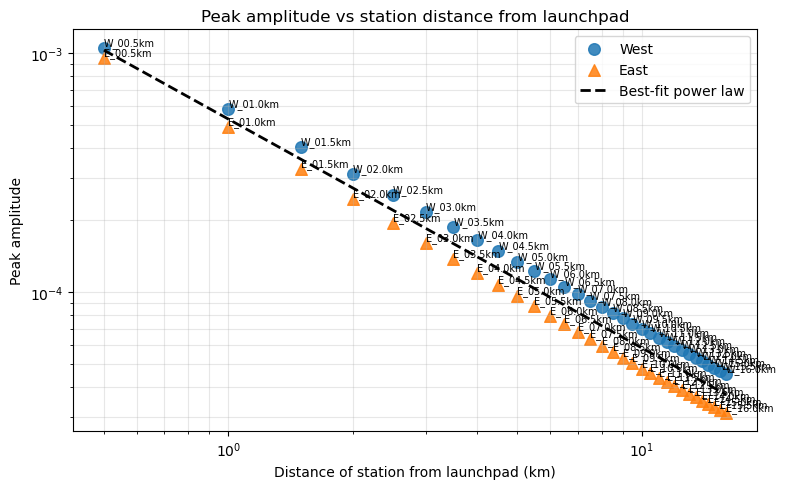

Amplitude fit (power law):
log10(A) = -3.2760 + -0.9577 log10(r)
A = 5.2964e-04 * r^-0.9577



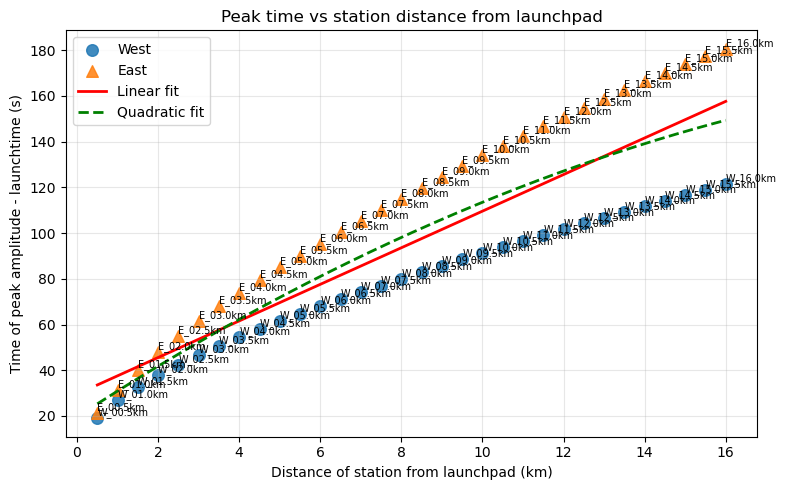

Time fit (linear):
t = 29.5685 + 8.0015 r

Time fit (quadratic):
t = 19.6087 + 11.5168 r + -0.2130 r^2

Apparent speed from linear fit: 125.0 m/s


In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Helper: extract station distance from synthetic station names like
# "W_08.0km" or "E_12.5km"
# ------------------------------------------------------------------
def station_name_to_distance_km(name: str) -> float:
    m = re.search(r'_(\d+(?:\.\d+)?)km', str(name))
    if not m:
        return np.nan
    return float(m.group(1))

# ------------------------------------------------------------------
# Copy and add distance-from-pad column
# ------------------------------------------------------------------
df = peak_df.copy()
df["station_distance_km"] = df["station"].apply(station_name_to_distance_km)

# Keep only valid rows
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["station_distance_km", "peak_amplitude", "peak_time_s"]).copy()
df = df[df["station_distance_km"] > 0].copy()

# Optional side label for plotting
df["side"] = df["station"].str[0].map({"W": "West", "E": "East"})

display(df.head())

# ==================================================================
# 1) Peak amplitude vs station distance from launchpad
# ------------------------------------------------------------------
# A straight line in linear space is usually not the best physical model.
# A power-law fit is usually more sensible:
#     A = C * r^b
# which is a straight line in log-log space:
#     log10(A) = a + b*log10(r), where C = 10^a
# ==================================================================
fit_amp = df[(df["peak_amplitude"] > 0)].copy()

x_amp = np.log10(fit_amp["station_distance_km"].values)
y_amp = np.log10(fit_amp["peak_amplitude"].values)

b_amp, a_amp = np.polyfit(x_amp, y_amp, 1)
C_amp = 10**a_amp

r_plot = np.linspace(fit_amp["station_distance_km"].min(),
                     fit_amp["station_distance_km"].max(), 300)
A_fit = C_amp * r_plot**b_amp

fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = fit_amp[fit_amp["side"] == side]
    ax.scatter(
        sub["station_distance_km"],
        sub["peak_amplitude"],
        s=70,
        marker=marker,
        label=side,
        alpha=0.85,
    )

ax.plot(r_plot, A_fit, "k--", linewidth=2, label="Best-fit power law")

for _, row in fit_amp.iterrows():
    ax.text(
        row["station_distance_km"],
        row["peak_amplitude"],
        row["station"],
        fontsize=7,
        ha="left",
        va="bottom",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Distance of station from launchpad (km)")
ax.set_ylabel("Peak amplitude")
ax.set_title("Peak amplitude vs station distance from launchpad")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

print("Amplitude fit (power law):")
print(f"log10(A) = {a_amp:.4f} + {b_amp:.4f} log10(r)")
print(f"A = {C_amp:.4e} * r^{b_amp:.4f}")
print()

# ==================================================================
# 2) Time of peak amplitude minus launchtime vs station distance
# ------------------------------------------------------------------
# For synthetic model output, peak_time_s is already "time since liftoff".
# So this is just peak_time_s vs station_distance_km.
#
# We fit:
#   linear:    t = a1 + b1*r
#   quadratic: t = a2 + b2*r + c2*r^2
# ==================================================================
fit_t = df.copy()

x_t = fit_t["station_distance_km"].values
y_t = fit_t["peak_time_s"].values

# Linear fit
b1, a1 = np.polyfit(x_t, y_t, 1)

# Quadratic fit
c2, b2, a2 = np.polyfit(x_t, y_t, 2)

r_plot_t = np.linspace(x_t.min(), x_t.max(), 300)
t_lin = a1 + b1 * r_plot_t
t_quad = a2 + b2 * r_plot_t + c2 * r_plot_t**2

fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = fit_t[fit_t["side"] == side]
    ax.scatter(
        sub["station_distance_km"],
        sub["peak_time_s"],
        s=70,
        marker=marker,
        label=side,
        alpha=0.85,
    )

ax.plot(r_plot_t, t_lin, "r-", linewidth=2, label="Linear fit")
ax.plot(r_plot_t, t_quad, "g--", linewidth=2, label="Quadratic fit")

for _, row in fit_t.iterrows():
    ax.text(
        row["station_distance_km"],
        row["peak_time_s"],
        row["station"],
        fontsize=7,
        ha="left",
        va="bottom",
    )

ax.set_xlabel("Distance of station from launchpad (km)")
ax.set_ylabel("Time of peak amplitude - launchtime (s)")
ax.set_title("Peak time vs station distance from launchpad")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

print("Time fit (linear):")
print(f"t = {a1:.4f} + {b1:.4f} r")
print()

print("Time fit (quadratic):")
print(f"t = {a2:.4f} + {b2:.4f} r + {c2:.4f} r^2")
print()

# Optional: convert linear slope into an apparent speed
# Here r is in km, so slope is s/km.
# speed = 1000 / slope  [m/s]
if b1 > 0:
    v_app = 1000.0 / b1
    print(f"Apparent speed from linear fit: {v_app:.1f} m/s")